<a href="https://colab.research.google.com/gist/dony230441100041/96080783e9b7325436599a575224dac5/tugas2deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import shutil

mount_point = "/content/drive"

if os.path.exists(mount_point):
    print("Folder /content/drive ditemukan.")

    # Hapus folder mount lama jika bukan symlink
    if not os.path.islink(mount_point):
        shutil.rmtree(mount_point)

        print("Folder /content/drive lama berhasil dihapus.")

os.makedirs(mount_point, exist_ok=True)

print("Folder mount siap.")

Folder /content/drive ditemukan.
Folder /content/drive lama berhasil dihapus.
Folder mount siap.


In [5]:
# ============================================================
# CIFAR-10 DEEP LEARNING EXPERIMENT
# MODEL A: CUSTOM CNN
# MODEL B: MINI-RESNET
#
# Semua hasil disimpan ke:
# Google Drive / MyDrive / CIFAR-10
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
import sys
import time
import json
import pickle
import random
import subprocess
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report


# ============================================================
# 2. LOGGING
# ============================================================

_ICONS = {
    "INFO": "ℹ️ ",
    "STEP": "🔹",
    "OK": "✅",
    "WARN": "⚠️ ",
    "ERROR": "❌"
}


def log_step(message, level="INFO"):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] {_ICONS.get(level, '•')} {message}")


def log_section(title):
    print("\n" + "=" * 78)
    print(f"  {title}")
    print("=" * 78)


# ============================================================
# 3. GOOGLE DRIVE
# ============================================================

log_section("TAHAP 1 — Google Drive Mounting & Setup Direktori")

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:

    from google.colab import drive

    log_step("Mounting Google Drive...", "STEP")

    drive.mount("/content/drive", force_remount=False)

    log_step("Google Drive berhasil di-mount.", "OK")

    # FOLDER UTAMA
    BASE_DIR = "/content/drive/MyDrive/CIFAR-10"

else:

    log_step(
        "Tidak berjalan di Google Colab — menggunakan folder lokal.",
        "WARN"
    )

    BASE_DIR = "./CIFAR-10"


# ============================================================
# 4. BUAT FOLDER HASIL
# ============================================================

DIRS = {

    "base": BASE_DIR,

    "grafik": os.path.join(
        BASE_DIR,
        "grafik"
    ),

    "grafik_visualisasi": os.path.join(
        BASE_DIR,
        "grafik_visualisasi"
    ),

    "cache": os.path.join(
        BASE_DIR,
        "cache"
    ),

    "laporan": os.path.join(
        BASE_DIR,
        "laporan"
    ),

    "error_analysis": os.path.join(
        BASE_DIR,
        "error_analysis"
    ),
}


for name, path in DIRS.items():

    os.makedirs(
        path,
        exist_ok=True
    )

    log_step(
        f"Direktori '{name}' siap -> {path}",
        "OK"
    )


# ============================================================
# 5. INSTALL PYTHON-DOCX
# ============================================================

try:

    import docx

except ImportError:

    log_step(
        "python-docx belum terpasang, menginstal...",
        "STEP"
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "python-docx"
        ],
        check=True
    )

    log_step(
        "python-docx berhasil diinstal.",
        "OK"
    )


# ============================================================
# 6. KONFIGURASI EKSPERIMEN
# ============================================================

log_section("TAHAP 2 — Konfigurasi Eksperimen")


CONFIG = {

    "seed": 42,

    "batch_size": 128,

    "epochs": 15,

    "lr": 1e-3,

    "val_split": 0.1,

    "num_workers": 2,

    "dpi": 300,
}


CLASS_NAMES = [

    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"

]


# ============================================================
# 7. RANDOM SEED
# ============================================================

def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


set_seed(
    CONFIG["seed"]
)


# ============================================================
# 8. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


log_step(
    f"Perangkat komputasi: {DEVICE}",
    "INFO"
)


if DEVICE.type == "cuda":

    log_step(
        f"GPU terdeteksi: {torch.cuda.get_device_name(0)}",
        "INFO"
    )

else:

    log_step(
        "GPU tidak terdeteksi, training berjalan di CPU.",
        "WARN"
    )


log_step(
    f"Konfigurasi:\n{json.dumps(CONFIG, indent=2)}",
    "INFO"
)


# ============================================================
# 9. COUNT PARAMETER
# ============================================================

def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )


# ============================================================
# 10. LOAD DATASET CIFAR-10
# ============================================================

def get_dataloaders(config):

    log_section(
        "TAHAP 3 — Memuat Dataset CIFAR-10"
    )


    mean = (
        0.4914,
        0.4822,
        0.4465
    )

    std = (
        0.2470,
        0.2435,
        0.2616
    )


    # TRAIN TRANSFORM

    train_transform = transforms.Compose([

        transforms.RandomCrop(
            32,
            padding=4
        ),

        transforms.RandomHorizontalFlip(),

        transforms.ToTensor(),

        transforms.Normalize(
            mean,
            std
        )

    ])


    # VALIDATION / TEST TRANSFORM

    eval_transform = transforms.Compose([

        transforms.ToTensor(),

        transforms.Normalize(
            mean,
            std
        )

    ])


    log_step(
        "Mengunduh/memuat CIFAR-10 train...",
        "STEP"
    )


    full_train = torchvision.datasets.CIFAR10(

        root="./data",

        train=True,

        download=True,

        transform=train_transform

    )


    full_train_eval = torchvision.datasets.CIFAR10(

        root="./data",

        train=True,

        download=True,

        transform=eval_transform

    )


    log_step(
        "Mengunduh/memuat CIFAR-10 test...",
        "STEP"
    )


    test_set = torchvision.datasets.CIFAR10(

        root="./data",

        train=False,

        download=True,

        transform=eval_transform

    )


    # DATA MENTAH UNTUK ERROR ANALYSIS

    raw_test_set = torchvision.datasets.CIFAR10(

        root="./data",

        train=False,

        download=True,

        transform=transforms.ToTensor()

    )


    # ========================================================
    # SPLIT TRAIN / VALIDATION
    # ========================================================

    n_val = int(
        len(full_train)
        * config["val_split"]
    )

    n_train = (
        len(full_train)
        - n_val
    )


    generator = torch.Generator().manual_seed(
        config["seed"]
    )


    train_subset, val_subset = random_split(

        range(len(full_train)),

        [
            n_train,
            n_val
        ],

        generator=generator

    )


    train_set = torch.utils.data.Subset(

        full_train,

        train_subset.indices

    )


    val_set = torch.utils.data.Subset(

        full_train_eval,

        val_subset.indices

    )


    train_loader = DataLoader(

        train_set,

        batch_size=config["batch_size"],

        shuffle=True,

        num_workers=config["num_workers"]

    )


    val_loader = DataLoader(

        val_set,

        batch_size=config["batch_size"],

        shuffle=False,

        num_workers=config["num_workers"]

    )


    test_loader = DataLoader(

        test_set,

        batch_size=config["batch_size"],

        shuffle=False,

        num_workers=config["num_workers"]

    )


    log_step(

        f"Jumlah data -> "
        f"train: {len(train_set)}, "
        f"val: {len(val_set)}, "
        f"test: {len(test_set)}",

        "OK"
    )


    return (

        train_loader,
        val_loader,
        test_loader,
        raw_test_set

    )


# ============================================================
# 11. MODEL A — SIMPLE CNN
# ============================================================

class ModelA_SimpleCNN(nn.Module):

    def __init__(
        self,
        num_classes=10,
        use_dropout=True,
        dropout_p=0.4
    ):

        super().__init__()

        self.use_dropout = use_dropout


        self.block1 = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)

        )


        self.block2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)

        )


        self.block3 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)

        )


        self.dropout = nn.Dropout(
            dropout_p
        )


        self.fc1 = nn.Linear(

            128 * 4 * 4,

            256

        )


        self.relu_fc = nn.ReLU(
            inplace=True
        )


        self.fc2 = nn.Linear(

            256,

            num_classes

        )


    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = torch.flatten(
            x,
            1
        )


        if self.use_dropout:

            x = self.dropout(x)


        x = self.relu_fc(
            self.fc1(x)
        )


        if self.use_dropout:

            x = self.dropout(x)


        return self.fc2(x)


# ============================================================
# 12. RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()


        self.conv1 = nn.Conv2d(

            in_channels,

            out_channels,

            3,

            stride=stride,

            padding=1,

            bias=False

        )


        self.bn1 = nn.BatchNorm2d(
            out_channels
        )


        self.conv2 = nn.Conv2d(

            out_channels,

            out_channels,

            3,

            stride=1,

            padding=1,

            bias=False

        )


        self.bn2 = nn.BatchNorm2d(
            out_channels
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.shortcut = nn.Sequential()


        if (

            stride != 1

            or in_channels != out_channels

        ):

            self.shortcut = nn.Sequential(

                nn.Conv2d(

                    in_channels,

                    out_channels,

                    1,

                    stride=stride,

                    bias=False

                ),

                nn.BatchNorm2d(
                    out_channels
                )

            )


    def forward(self, x):

        identity = self.shortcut(x)


        out = self.conv1(x)

        out = self.bn1(out)

        out = self.relu(out)


        out = self.conv2(out)

        out = self.bn2(out)


        out = out + identity

        out = self.relu(out)


        return out


# ============================================================
# 13. MODEL B — MINI RESNET
# ============================================================

class ModelB_MiniResNet(nn.Module):

    def __init__(
        self,
        num_classes=10,
        num_blocks=(2, 2, 2)
    ):

        super().__init__()


        self.in_channels = 32


        self.stem = nn.Sequential(

            nn.Conv2d(

                3,

                32,

                3,

                padding=1,

                bias=False

            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True)

        )


        self.stage1 = self._make_stage(

            32,

            num_blocks[0],

            stride=1

        )


        self.stage2 = self._make_stage(

            64,

            num_blocks[1],

            stride=2

        )


        self.stage3 = self._make_stage(

            128,

            num_blocks[2],

            stride=2

        )


        self.pool = nn.AdaptiveAvgPool2d(1)


        self.fc = nn.Linear(

            128,

            num_classes

        )


    def _make_stage(

        self,

        out_channels,

        n_blocks,

        stride

    ):

        layers = [

            ResidualBlock(

                self.in_channels,

                out_channels,

                stride

            )

        ]


        self.in_channels = out_channels


        for _ in range(
            n_blocks - 1
        ):

            layers.append(

                ResidualBlock(

                    out_channels,

                    out_channels,

                    stride=1

                )

            )


        return nn.Sequential(
            *layers
        )


    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.pool(x)

        x = torch.flatten(
            x,
            1
        )

        return self.fc(x)


# ============================================================
# 14. RUN ONE EPOCH
# ============================================================

def run_one_epoch(

    model,

    loader,

    criterion,

    optimizer=None

):

    is_train = optimizer is not None


    if is_train:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_correct = 0

    total_samples = 0


    context = (

        torch.enable_grad()

        if is_train

        else torch.no_grad()

    )


    with context:

        for images, labels in loader:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            if is_train:

                optimizer.zero_grad()


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            if is_train:

                loss.backward()

                optimizer.step()


            total_loss += (

                loss.item()
                * images.size(0)

            )


            total_correct += (

                outputs.argmax(1)
                == labels

            ).sum().item()


            total_samples += (
                images.size(0)
            )


    return (

        total_loss
        / total_samples,

        total_correct
        / total_samples

    )


# ============================================================
# 15. TRAINING
# ============================================================

def train_model(

    model,

    train_loader,

    val_loader,

    config,

    model_name="model"

):

    model = model.to(
        DEVICE
    )


    criterion = nn.CrossEntropyLoss()


    optimizer = optim.Adam(

        model.parameters(),

        lr=config["lr"]

    )


    history = {

        "train_loss": [],

        "val_loss": [],

        "train_acc": [],

        "val_acc": []

    }


    log_section(
        f"Training {model_name}"
    )


    log_step(

        f"Jumlah parameter: "
        f"{count_parameters(model):,}",

        "INFO"

    )


    start_time = time.time()


    for epoch in range(
        config["epochs"]
    ):


        train_loss, train_acc = run_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer

        )


        val_loss, val_acc = run_one_epoch(

            model,

            val_loader,

            criterion

        )


        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )


        log_step(

            f"Epoch "
            f"{epoch + 1:02d}/"
            f"{config['epochs']} | "

            f"train_loss={train_loss:.4f} "

            f"val_loss={val_loss:.4f} | "

            f"train_acc={train_acc:.4f} "

            f"val_acc={val_acc:.4f}",

            "STEP"

        )


    total_time = (
        time.time()
        - start_time
    )


    log_step(

        f"Training {model_name} "
        f"selesai dalam "
        f"{total_time:.1f} detik.",

        "OK"

    )


    return (

        model,

        history,

        total_time

    )


# ============================================================
# 16. EVALUASI TEST
# ============================================================

def evaluate_on_test(

    model,

    test_loader,

    model_name="model"

):

    model.eval()


    all_preds = []

    all_labels = []


    criterion = nn.CrossEntropyLoss()


    total_loss = 0.0

    total_correct = 0

    total_samples = 0


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            outputs = model(images)


            loss = criterion(

                outputs,

                labels

            )


            total_loss += (

                loss.item()
                * images.size(0)

            )


            preds = outputs.argmax(1)


            total_correct += (

                preds == labels

            ).sum().item()


            total_samples += (
                images.size(0)
            )


            all_preds.extend(

                preds.cpu().numpy()

            )


            all_labels.extend(

                labels.cpu().numpy()

            )


    test_loss = (

        total_loss
        / total_samples

    )


    test_acc = (

        total_correct
        / total_samples

    )


    cm = confusion_matrix(

        all_labels,

        all_preds

    )


    report = classification_report(

        all_labels,

        all_preds,

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0

    )


    log_step(

        f"[{model_name}] TEST -> "
        f"loss={test_loss:.4f} "
        f"acc={test_acc:.4f}",

        "OK"

    )


    return {

        "test_loss": test_loss,

        "test_acc": test_acc,

        "confusion_matrix": cm,

        "classification_report": report,

        "preds": np.array(all_preds),

        "labels": np.array(all_labels)

    }


# ============================================================
# 17. SAVE FIGURE
# ============================================================

def save_fig(

    filename,

    directory=None

):

    if directory is None:

        directory = DIRS["grafik"]


    path = os.path.join(

        directory,

        filename

    )


    plt.tight_layout()


    plt.savefig(

        path,

        dpi=CONFIG["dpi"],

        bbox_inches="tight"

    )


    plt.close()


    log_step(

        f"Grafik tersimpan -> {path}",

        "OK"

    )


    return path


# ============================================================
# 18. PLOT CURVES
# ============================================================

def plot_curves(

    histories,

    key,

    ylabel,

    filename

):

    plt.figure(
        figsize=(9, 6)
    )


    for name, hist in histories.items():

        plt.plot(

            hist[key],

            marker="o",

            linewidth=2,

            label=name

        )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"{ylabel} per Epoch"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )


    return save_fig(
        filename
    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix(

    cm,

    title,

    filename

):

    plt.figure(
        figsize=(9, 7)
    )


    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=CLASS_NAMES,

        yticklabels=CLASS_NAMES

    )


    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.title(
        title
    )


    return save_fig(
        filename
    )


# ============================================================
# 20. ERROR ANALYSIS
# ============================================================

def two_way_error_analysis(

    eval_a,

    eval_b,

    raw_test_set,

    n_examples=6

):

    log_section(
        "TAHAP — Error Analysis"
    )


    preds_a = eval_a["preds"]

    preds_b = eval_b["preds"]

    labels = eval_a["labels"]


    idx_a_wrong_b_right = np.where(

        (preds_a != labels)
        &
        (preds_b == labels)

    )[0]


    idx_b_wrong_a_right = np.where(

        (preds_b != labels)
        &
        (preds_a == labels)

    )[0]


    log_step(

        f"Model A salah, Model B benar: "
        f"{len(idx_a_wrong_b_right)} citra",

        "INFO"

    )


    log_step(

        f"Model B salah, Model A benar: "
        f"{len(idx_b_wrong_a_right)} citra",

        "INFO"

    )


    result = {

        "n_a_wrong_b_right":
            int(len(idx_a_wrong_b_right)),

        "n_b_wrong_a_right":
            int(len(idx_b_wrong_a_right)),

        "example_path": None

    }


    n = min(

        n_examples,

        len(idx_a_wrong_b_right),

        len(idx_b_wrong_a_right)

    )


    if n == 0:

        return result


    rng = np.random.default_rng(
        CONFIG["seed"]
    )


    sample_a = rng.choice(

        idx_a_wrong_b_right,

        n,

        replace=False

    )


    sample_b = rng.choice(

        idx_b_wrong_a_right,

        n,

        replace=False

    )


    fig, axes = plt.subplots(

        2,

        n,

        figsize=(2.5 * n, 5)

    )


    if n == 1:

        axes = np.array(
            axes
        ).reshape(2, 1)


    for col, idx in enumerate(
        sample_a
    ):

        img, _ = raw_test_set[
            int(idx)
        ]


        axes[0, col].imshow(

            img.permute(
                1,
                2,
                0
            ).numpy()

        )


        axes[0, col].set_title(

            f"True: "
            f"{CLASS_NAMES[labels[idx]]}\n"

            f"A: "
            f"{CLASS_NAMES[preds_a[idx]]}\n"

            f"B: "
            f"{CLASS_NAMES[preds_b[idx]]}",

            fontsize=8

        )


        axes[0, col].axis(
            "off"
        )


    for col, idx in enumerate(
        sample_b
    ):

        img, _ = raw_test_set[
            int(idx)
        ]


        axes[1, col].imshow(

            img.permute(
                1,
                2,
                0
            ).numpy()

        )


        axes[1, col].set_title(

            f"True: "
            f"{CLASS_NAMES[labels[idx]]}\n"

            f"A: "
            f"{CLASS_NAMES[preds_a[idx]]}\n"

            f"B: "
            f"{CLASS_NAMES[preds_b[idx]]}",

            fontsize=8

        )


        axes[1, col].axis(
            "off"
        )


    fig.suptitle(

        "Error Analysis Dua Arah: "
        "Model A vs Model B",

        fontsize=13

    )


    plt.tight_layout()


    path = os.path.join(

        DIRS["error_analysis"],

        "error_analysis_dua_arah.png"

    )


    plt.savefig(

        path,

        dpi=CONFIG["dpi"],

        bbox_inches="tight"

    )


    plt.close()


    result["example_path"] = path


    log_step(

        f"Error analysis tersimpan -> {path}",

        "OK"

    )


    return result


# ============================================================
# 21. SAVE CACHE
# ============================================================

def save_cache(

    results,

    filename="cache.pkl"

):

    path = os.path.join(

        DIRS["cache"],

        filename

    )


    with open(
        path,
        "wb"
    ) as f:

        pickle.dump(
            results,
            f
        )


    log_step(

        f"Cache tersimpan -> {path}",

        "OK"

    )


    return path


# ============================================================
# 22. MAIN EXPERIMENT
# ============================================================

def main():

    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------

    (

        train_loader,

        val_loader,

        test_loader,

        raw_test_set

    ) = get_dataloaders(
        CONFIG
    )


    # --------------------------------------------------------
    # MODEL A
    # --------------------------------------------------------

    model_a, hist_a, time_a = train_model(

        ModelA_SimpleCNN(
            use_dropout=True
        ),

        train_loader,

        val_loader,

        CONFIG,

        "Model A (CNN)"

    )


    eval_a = evaluate_on_test(

        model_a,

        test_loader,

        "Model A (CNN)"

    )


    # --------------------------------------------------------
    # MODEL B
    # --------------------------------------------------------

    model_b, hist_b, time_b = train_model(

        ModelB_MiniResNet(

            num_blocks=(
                2,
                2,
                2
            )

        ),

        train_loader,

        val_loader,

        CONFIG,

        "Model B (Mini-ResNet)"

    )


    eval_b = evaluate_on_test(

        model_b,

        test_loader,

        "Model B (Mini-ResNet)"

    )


    # --------------------------------------------------------
    # ABLATION DROPOUT
    # --------------------------------------------------------

    model_a_nodrop, hist_a_nodrop, time_a_nodrop = train_model(

        ModelA_SimpleCNN(

            use_dropout=False

        ),

        train_loader,

        val_loader,

        CONFIG,

        "Model A tanpa Dropout"

    )


    eval_a_nodrop = evaluate_on_test(

        model_a_nodrop,

        test_loader,

        "Model A tanpa Dropout"

    )


    # --------------------------------------------------------
    # GRAFIK TRAINING
    # --------------------------------------------------------

    log_section(
        "TAHAP — Membuat Grafik Eksperimen"
    )


    histories = {

        "Model A (CNN)": hist_a,

        "Model B (Mini-ResNet)": hist_b

    }


    p1 = plot_curves(

        histories,

        "train_loss",

        "Training Loss",

        "01_training_loss.png"

    )


    p2 = plot_curves(

        histories,

        "val_loss",

        "Validation Loss",

        "02_validation_loss.png"

    )


    p3 = plot_curves(

        histories,

        "train_acc",

        "Training Accuracy",

        "03_training_accuracy.png"

    )


    p4 = plot_curves(

        histories,

        "val_acc",

        "Validation Accuracy",

        "04_validation_accuracy.png"

    )


    p5 = plot_confusion_matrix(

        eval_a["confusion_matrix"],

        "Confusion Matrix - Model A",

        "05_confusion_matrix_model_a.png"

    )


    p6 = plot_confusion_matrix(

        eval_b["confusion_matrix"],

        "Confusion Matrix - Model B",

        "06_confusion_matrix_model_b.png"

    )


    # --------------------------------------------------------
    # ABLATION GRAPH
    # --------------------------------------------------------

    ablation_histories = {

        "Dengan Dropout": hist_a,

        "Tanpa Dropout": hist_a_nodrop

    }


    p7 = plot_curves(

        ablation_histories,

        "train_acc",

        "Training Accuracy - Ablation",

        "07_ablation_training_accuracy.png"

    )


    p8 = plot_curves(

        ablation_histories,

        "val_acc",

        "Validation Accuracy - Ablation",

        "08_ablation_validation_accuracy.png"

    )


    # --------------------------------------------------------
    # ERROR ANALYSIS
    # --------------------------------------------------------

    error_analysis = two_way_error_analysis(

        eval_a,

        eval_b,

        raw_test_set,

        n_examples=6

    )


    # --------------------------------------------------------
    # GAP DROPOUT
    # --------------------------------------------------------

    gap_with = (

        hist_a["train_acc"][-1]

        -

        hist_a["val_acc"][-1]

    )


    gap_without = (

        hist_a_nodrop["train_acc"][-1]

        -

        hist_a_nodrop["val_acc"][-1]

    )


    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    results = {

        "config": CONFIG,

        "base_dir": BASE_DIR,

        "timestamp":
            datetime.now().isoformat(),


        "model_a": {

            "display_name":
                "Model A (CNN Custom)",

            "params":
                count_parameters(model_a),

            "training_time_sec":
                time_a,

            "test_loss":
                eval_a["test_loss"],

            "test_acc":
                eval_a["test_acc"],

            "confusion_matrix":
                eval_a["confusion_matrix"],

            "classification_report":
                eval_a["classification_report"],

            "history":
                hist_a

        },


        "model_b": {

            "display_name":
                "Model B (Mini-ResNet)",

            "params":
                count_parameters(model_b),

            "training_time_sec":
                time_b,

            "test_loss":
                eval_b["test_loss"],

            "test_acc":
                eval_b["test_acc"],

            "confusion_matrix":
                eval_b["confusion_matrix"],

            "classification_report":
                eval_b["classification_report"],

            "history":
                hist_b

        },


        "ablation": {

            "with_dropout": {

                "history":
                    hist_a,

                "final_train_acc":
                    hist_a["train_acc"][-1],

                "final_val_acc":
                    hist_a["val_acc"][-1],

                "test_acc":
                    eval_a["test_acc"],

                "train_val_gap":
                    gap_with

            },


            "without_dropout": {

                "history":
                    hist_a_nodrop,

                "final_train_acc":
                    hist_a_nodrop["train_acc"][-1],

                "final_val_acc":
                    hist_a_nodrop["val_acc"][-1],

                "test_acc":
                    eval_a_nodrop["test_acc"],

                "train_val_gap":
                    gap_without

            }

        },


        "error_analysis":
            error_analysis,


        "graph_paths": [

            (
                p1,
                "Training Loss"
            ),

            (
                p2,
                "Validation Loss"
            ),

            (
                p3,
                "Training Accuracy"
            ),

            (
                p4,
                "Validation Accuracy"
            ),

            (
                p5,
                "Confusion Matrix Model A"
            ),

            (
                p6,
                "Confusion Matrix Model B"
            ),

            (
                p7,
                "Ablation Training Accuracy"
            ),

            (
                p8,
                "Ablation Validation Accuracy"
            )

        ]

    }


    # --------------------------------------------------------
    # SAVE CACHE
    # --------------------------------------------------------

    save_cache(
        results,
        "cache.pkl"
    )


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    log_section(
        "RINGKASAN AKHIR"
    )


    log_step(

        f"Model A (CNN) -> "
        f"Accuracy: "
        f"{eval_a['test_acc']:.4f}",

        "OK"

    )


    log_step(

        f"Model B (Mini-ResNet) -> "
        f"Accuracy: "
        f"{eval_b['test_acc']:.4f}",

        "OK"

    )


    log_step(

        f"Ablation Dropout -> "
        f"Gap dengan dropout: "
        f"{gap_with:.4f}",

        "OK"

    )


    log_step(

        f"Ablation Dropout -> "
        f"Gap tanpa dropout: "
        f"{gap_without:.4f}",

        "OK"

    )


    log_step(

        f"SEMUA HASIL DISIMPAN DI:",

        "OK"

    )


    print(
        BASE_DIR
    )


    return results


# ============================================================
# 23. JALANKAN EKSPERIMEN
# ============================================================

results = main()


  TAHAP 1 — Google Drive Mounting & Setup Direktori
[07:17:25] 🔹 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[07:17:27] ✅ Google Drive berhasil di-mount.
[07:17:27] ✅ Direktori 'base' siap -> /content/drive/MyDrive/CIFAR-10
[07:17:27] ✅ Direktori 'grafik' siap -> /content/drive/MyDrive/CIFAR-10/grafik
[07:17:27] ✅ Direktori 'grafik_visualisasi' siap -> /content/drive/MyDrive/CIFAR-10/grafik_visualisasi
[07:17:27] ✅ Direktori 'cache' siap -> /content/drive/MyDrive/CIFAR-10/cache
[07:17:27] ✅ Direktori 'laporan' siap -> /content/drive/MyDrive/CIFAR-10/laporan
[07:17:27] ✅ Direktori 'error_analysis' siap -> /content/drive/MyDrive/CIFAR-10/error_analysis

  TAHAP 2 — Konfigurasi Eksperimen
[07:17:27] ℹ️  Perangkat komputasi: cpu
[07:17:27] ⚠️  GPU tidak terdeteksi, training berjalan di CPU.
[07:17:27] ℹ️  Konfigurasi:
{
  "seed": 42,
  "batch_size": 128,
  "epochs": 15,
  "lr": 0.

Visualisasi

In [7]:
print("=" * 60)
print("STRUKTUR RESULTS")
print("=" * 60)

for key, value in results.items():
    print(f"\nKEY: {key}")
    print("TYPE:", type(value))

    if isinstance(value, dict):
        print("SUB-KEY:", list(value.keys()))

STRUKTUR RESULTS

KEY: config
TYPE: <class 'dict'>
SUB-KEY: ['seed', 'batch_size', 'epochs', 'lr', 'val_split', 'num_workers', 'dpi']

KEY: base_dir
TYPE: <class 'str'>

KEY: timestamp
TYPE: <class 'str'>

KEY: model_a
TYPE: <class 'dict'>
SUB-KEY: ['display_name', 'params', 'training_time_sec', 'test_loss', 'test_acc', 'confusion_matrix', 'classification_report', 'history']

KEY: model_b
TYPE: <class 'dict'>
SUB-KEY: ['display_name', 'params', 'training_time_sec', 'test_loss', 'test_acc', 'confusion_matrix', 'classification_report', 'history']

KEY: ablation
TYPE: <class 'dict'>
SUB-KEY: ['with_dropout', 'without_dropout']

KEY: error_analysis
TYPE: <class 'dict'>
SUB-KEY: ['n_a_wrong_b_right', 'n_b_wrong_a_right', 'example_path']

KEY: graph_paths
TYPE: <class 'list'>


**grafik Model A**

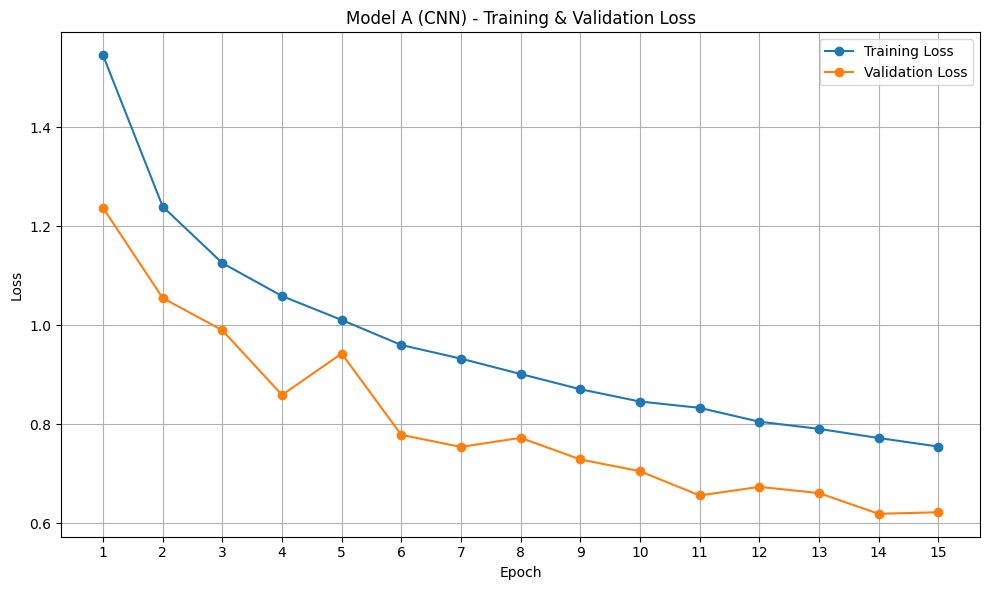

✅ Grafik loss tersimpan:
/content/drive/MyDrive/CIFAR-10/grafik_visualisasi/model_a_loss.png


In [8]:
import matplotlib.pyplot as plt
import os

# Ambil history Model A
history_a = results["model_a"]["history"]

epochs = range(1, len(history_a["train_loss"]) + 1)

# ==============================
# GRAFIK LOSS
# ==============================
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_a["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history_a["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Model A (CNN) - Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()

# Simpan ke Google Drive
save_path = os.path.join(
    results["base_dir"],
    "grafik_visualisasi",
    "model_a_loss.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Grafik loss tersimpan:")
print(save_path)

**Accuracy Model A**

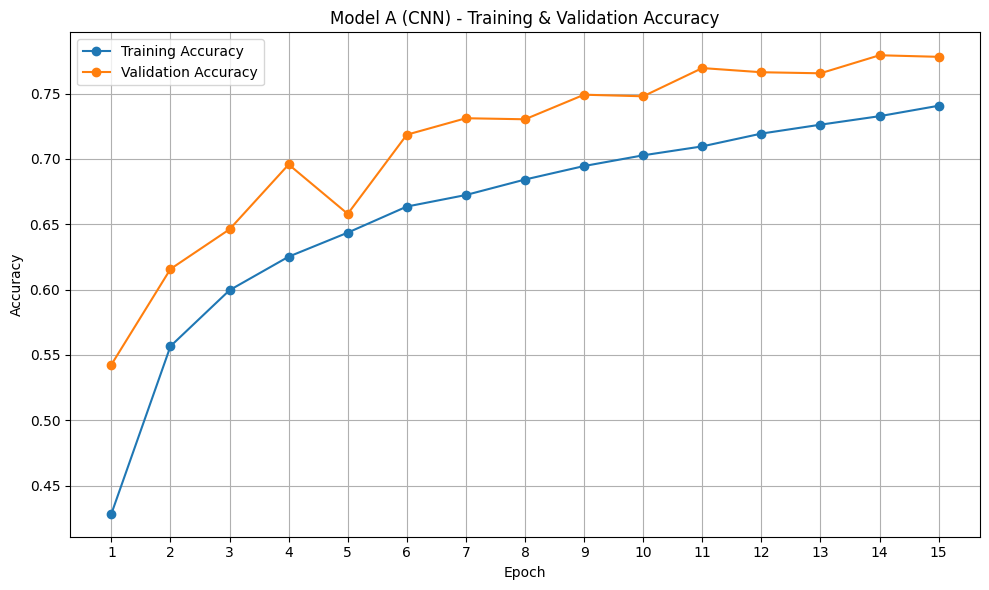

✅ Grafik accuracy tersimpan:
/content/drive/MyDrive/CIFAR-10/grafik_visualisasi/model_a_accuracy.png


In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_a["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_a["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Model A (CNN) - Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()

save_path = os.path.join(
    results["base_dir"],
    "grafik_visualisasi",
    "model_a_accuracy.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Grafik accuracy tersimpan:")
print(save_path)

**Confusion Matrix Model A**

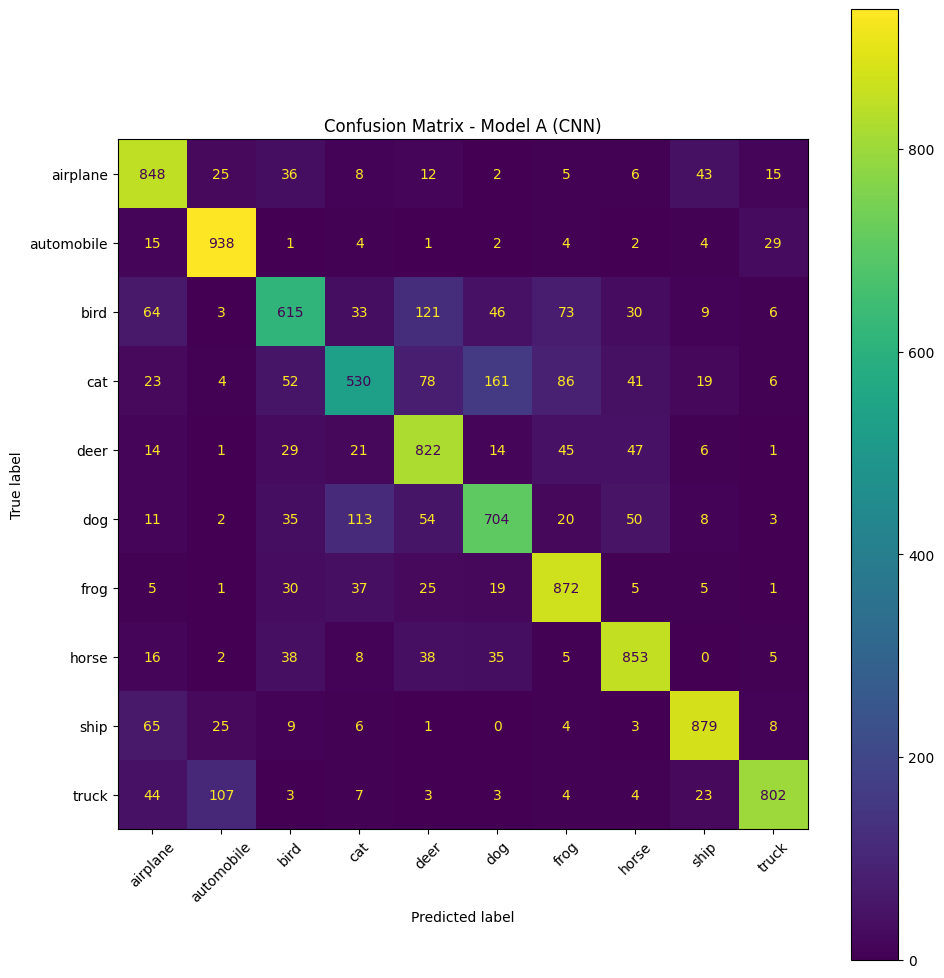

✅ Confusion Matrix tersimpan:
/content/drive/MyDrive/CIFAR-10/grafik_visualisasi/confusion_matrix_model_a.png


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_a = results["model_a"]["confusion_matrix"]

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_a,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title("Confusion Matrix - Model A (CNN)")

plt.tight_layout()

save_path = os.path.join(
    results["base_dir"],
    "grafik_visualisasi",
    "confusion_matrix_model_a.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Confusion Matrix tersimpan:")
print(save_path)

**Classification Report**

In [11]:
print("=" * 70)
print("CLASSIFICATION REPORT - MODEL A (CNN)")
print("=" * 70)

print(results["model_a"]["classification_report"])

CLASSIFICATION REPORT - MODEL A (CNN)
{'airplane': {'precision': 0.7674208144796381, 'recall': 0.848, 'f1-score': 0.8057007125890736, 'support': 1000.0}, 'automobile': {'precision': 0.8465703971119134, 'recall': 0.938, 'f1-score': 0.889943074003795, 'support': 1000.0}, 'bird': {'precision': 0.7252358490566038, 'recall': 0.615, 'f1-score': 0.6655844155844156, 'support': 1000.0}, 'cat': {'precision': 0.6910039113428944, 'recall': 0.53, 'f1-score': 0.5998868138087153, 'support': 1000.0}, 'deer': {'precision': 0.7116883116883117, 'recall': 0.822, 'f1-score': 0.762877030162413, 'support': 1000.0}, 'dog': {'precision': 0.7139959432048681, 'recall': 0.704, 'f1-score': 0.7089627391742196, 'support': 1000.0}, 'frog': {'precision': 0.7799642218246869, 'recall': 0.872, 'f1-score': 0.8234183191690274, 'support': 1000.0}, 'horse': {'precision': 0.8194044188280499, 'recall': 0.853, 'f1-score': 0.8358647721705047, 'support': 1000.0}, 'ship': {'precision': 0.8825301204819277, 'recall': 0.879, 'f1-scor

**Tampilkan hasil utama Model A**

In [12]:
model_a = results["model_a"]

print("=" * 60)
print("HASIL MODEL A (CNN)")
print("=" * 60)

print(f"Jumlah Parameter : {model_a['params']:,}")
print(f"Waktu Training   : {model_a['training_time_sec']:.2f} detik")
print(f"Test Loss        : {model_a['test_loss']:.4f}")
print(f"Test Accuracy    : {model_a['test_acc']:.4f}")
print(f"Test Accuracy    : {model_a['test_acc'] * 100:.2f}%")

HASIL MODEL A (CNN)
Jumlah Parameter : 620,810
Waktu Training   : 2000.44 detik
Test Loss        : 0.6287
Test Accuracy    : 0.7863
Test Accuracy    : 78.63%


In [13]:
from google.colab import files
import shutil

shutil.make_archive(
    "/content/CIFAR-10",
    "zip",
    "/content/drive/MyDrive/CIFAR-10"
)

files.download("/content/CIFAR-10.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>